<a href="https://colab.research.google.com/github/soralh1611/vertex-ai/blob/main/Credit_Underwriting_Model_w_Gen_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os



# Download latest version
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lending-club-loan-data-csv' dataset.
Path to dataset files: /kaggle/input/lending-club-loan-data-csv


In [29]:


csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if not csv_files:
    print("Error: No CSV files found in the downloaded directory.")
    # You might need to adjust the file name based on the specific dataset structure
    # For a generic example, we'll assume the largest file is the one we want.
else:
    # Assuming the first CSV file found is the main data file
    csv_file_path = os.path.join(path, csv_files[0])
    print(f"Loading data from: {csv_file_path}")

    # 3. Load the data into a Pandas DataFrame
    # Note: Large files may require specifying dtype or using chunking.
    # This dataset is likely several hundred MBs to a few GBs.
    try:
        df = pd.read_csv(csv_file_path)

        # 4. Inspect the data
        print("\n--- First 5 Rows (df.head()) ---")
        print(df.head()) # Displays the first 5 rows and column names

        print("\n--- Column Information (df.info()) ---")
        df.info() # Displays non-null counts, data types, and memory usage

        print("\n--- Summary Statistics (df.describe()) ---")
        print(df.describe().T) # Displays mean, min, max, std, quartiles for numeric columns

        # Calculate and display the percentage of missing values
        print("\n--- Percentage of Missing Values (NA%) ---")
        missing_percentage = df.isnull().sum() * 100 / len(df)
        print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

    except Exception as e:
        print(f"An error occurred while reading the CSV: {e}")
        print("You may need to manually confirm the correct CSV file name or use a specific encoding.")

Loading data from: /kaggle/input/lending-club-loan-data-csv/loan.csv


/tmp/ipython-input-2024577621.py:16: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)



--- First 5 Rows (df.head()) ---
   id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0 NaN        NaN       2500         2500           2500.0   36 months   
1 NaN        NaN      30000        30000          30000.0   60 months   
2 NaN        NaN       5000         5000           5000.0   36 months   
3 NaN        NaN       4000         4000           4000.0   36 months   
4 NaN        NaN      30000        30000          30000.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.56        84.92     C        C1  ...                            NaN   
1     18.94       777.23     D        D2  ...                            NaN   
2     17.97       180.69     D        D1  ...                            NaN   
3     18.94       146.51     D        D2  ...                            NaN   
4     16.14       731.78     C        C4  ...                            NaN   

  hardship_last_payment_amount disbursement_me

In [30]:
# Define the list of loan statuses that you consider a "Default" (1)
default_statuses = [
    'Late (31-120 days)',
    'In Grace Period',
    'Charged Off',
    'Default',
    # Note: Depending on your dataset, you might also want to include 'Late (16-30 days)', etc.
    # Always check the unique values first!
]

# Create the new binary column 'default_flag'
# Initialize the column with 0 (Non-Default)
df['default_flag'] = 0

# Set the 'default_flag' to 1 (Default) for all rows where 'loan_status' is in the list
df.loc[df['loan_status'].isin(default_statuses), 'default_flag'] = 1

# Display the distribution of the new target variable to confirm the change
print("--- Distribution of New Target Variable ('default_flag') ---")
print(df['default_flag'].value_counts())

print("\n--- Percentage Distribution ---")
print(df['default_flag'].value_counts(normalize=True) * 100)

--- Distribution of New Target Variable ('default_flag') ---
default_flag
0    1968133
1     292535
Name: count, dtype: int64

--- Percentage Distribution ---
default_flag
0    87.059798
1    12.940202
Name: proportion, dtype: float64


In [31]:
# Calculate the percentage of missing data for each column
null_percentages = df.isnull().sum() / len(df)
# Define a threshold (e.g., 70%)
high_null_cols = null_percentages[null_percentages > 0.7].index.tolist()

print(f"\nColumns dropped due to >70% nulls: {high_null_cols}")
df.drop(columns=high_null_cols, inplace=True)


Columns dropped due to >70% nulls: ['id', 'member_id', 'url', 'desc', 'mths_since_last_record', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'mths_since_recent_bc_dlq', 'revol_bal_joint', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term']


In [32]:
# Identify data types after dropping high-null columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# --- Impute Numeric (Median) ---
print("\n--- Numeric Imputation ---")
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        # print(f"Imputed '{col}' with median: {median_val}")

# --- Impute Categorical (Mode) ---
print("\n--- Categorical Imputation ---")
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        # print(f"Imputed '{col}' with mode: {mode_val}")

print(f"Total null values remaining: {df.isnull().sum().sum()}")


--- Numeric Imputation ---


/tmp/ipython-input-1076453860.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)



--- Categorical Imputation ---


/tmp/ipython-input-1076453860.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


Total null values remaining: 0


In [33]:
if 'loan_status' in df.columns:
    df.drop('loan_status', axis=1, inplace=True)
    print("Dropped the original 'loan_status' column.")

Dropped the original 'loan_status' column.


In [34]:
# Assuming your cleaned and prepped data is stored in the DataFrame named 'df'

# Get the Index object of column names
column_names_index = df.columns

# Convert the Index object to a standard Python list
column_list = column_names_index.tolist()

print("--- Column List ---")
print(column_list)
print(f"\nTotal number of columns: {len(column_list)}")

--- Column List ---
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'tota

In [35]:
# 1. Define the columns to be removed/dropped
columns_to_drop = [
    'title',
    'zip_code',
    'addr_state',
    'earliest_cr_line',
    'initial_list_status',
    'last_pymnt_d',
    'next_pymnt_d',
    'last_credit_pull_d',
    'emp_title',
    'emp_length',
    'issue_d', 'next_pymnt_d', 'pymnt_plan', 'recoveries', 'revol_bal', 'revol_util', 'tot_coll_amt', 'tot_cur_bal', 'tot_hi_cred_lim', 'total_acc', 'total_bal_ex_mort', 'total_bal_il', 'total_bc_limit', 'total_cu_tl', 'total_il_high_credit_limit', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_late_fee', 'total_rec_prncp', 'total_rev_hi_lim', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term', 'collection_recovery_fee', 'out_prncp', 'out_prncp_inv', 'last_pymnt_amnt', 'int_rate', 'term', 'disbursement_method','grade','sub_grade'
]

# 2. Drop the columns from the DataFrame (df)
# We use errors='ignore' in case a column was already dropped earlier
df.drop(columns=columns_to_drop, errors='ignore', inplace=True)
print(f"Dropped the following columns from the DataFrame: {columns_to_drop}")

# 3. Re-identify the current categorical columns for OHE
# We check for remaining 'object' type columns
categorical_cols_for_ohe = df.select_dtypes(include=['object']).columns.tolist()

if not categorical_cols_for_ohe:
    print("\nNo 'object' type columns remain for One-Hot Encoding.")
else:
    print(f"\nRemaining categorical columns for OHE are: {categorical_cols_for_ohe}")

# Now you can proceed with the refined One-Hot Encoding step:
# 4. Perform One-Hot Encoding on the remaining categorical columns
if categorical_cols_for_ohe:
    # drop_first=True removes one category from each feature to avoid multicollinearity
    df = pd.get_dummies(df, columns=categorical_cols_for_ohe, drop_first=True)

    print(f"\nSuccessfully applied One-Hot Encoding to the remaining {len(categorical_cols_for_ohe)} columns.")
    print(f"Final DataFrame shape: {df.shape}")

Dropped the following columns from the DataFrame: ['title', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'emp_title', 'emp_length', 'issue_d', 'next_pymnt_d', 'pymnt_plan', 'recoveries', 'revol_bal', 'revol_util', 'tot_coll_amt', 'tot_cur_bal', 'tot_hi_cred_lim', 'total_acc', 'total_bal_ex_mort', 'total_bal_il', 'total_bc_limit', 'total_cu_tl', 'total_il_high_credit_limit', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_late_fee', 'total_rec_prncp', 'total_rev_hi_lim', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term', 'collection_recovery_fee', 'out_prncp', 'out_prncp_inv', 'last_pymnt_amnt', 'int_rate', 'term', 'disbursement_method', 'grade', 'sub_grade']

Remaining categorical columns for OHE are: ['home_ownership', 'verification_status', 'purpose', 'application_type', 'hardship_flag', 'debt_settlement_flag']

Successfully applied One-Hot Encoding to the rema

In [36]:
# Assuming you have already calculated the full correlation matrix:
corr_matrix = df.corr()

# 1. Recalculate Highly Correlated Pairs (r >= 0.8)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_correlated_pairs = []

# Exclude the target variable from the upper matrix for this check
features_to_check = [col for col in upper.columns if col != 'default_flag']

for col1 in features_to_check:
    for col2 in features_to_check:
        if col1 != col2:
            correlation = upper.loc[col1, col2]
            if abs(correlation) >= 0.8:
                highly_correlated_pairs.append((col1, col2, correlation))

# 2. Iterate through pairs and select the one to drop
features_to_drop = set()
target_corr_series = corr_matrix['default_flag'].abs()

print("\n--- Decision Process for Dropping Redundant Features ---")

for col1, col2, corr in highly_correlated_pairs:
    if col1 in features_to_drop or col2 in features_to_drop:
        # Skip if one of the features has already been chosen to be dropped
        continue

    # Get the absolute correlation of each feature with the target
    corr1_target = target_corr_series.get(col1, 0)
    corr2_target = target_corr_series.get(col2, 0)

    # Compare and decide which feature to drop (the one with the LOWER target correlation)
    if corr1_target < corr2_target:
        features_to_drop.add(col1)
        print(f"Dropping '{col1}' (Target Corr: {corr1_target:.4f}) because it is highly correlated with '{col2}' (Target Corr: {corr2_target:.4f})")
    else:
        features_to_drop.add(col2)
        print(f"Dropping '{col2}' (Target Corr: {corr2_target:.4f}) because it is highly correlated with '{col1}' (Target Corr: {corr1_target:.4f})")


# 3. Execute the Drop
if features_to_drop:
    df.drop(columns=list(features_to_drop), inplace=True)
    print(f"\n--- Final Action ---")
    print(f"Total number of features dropped: {len(features_to_drop)}")
    print(f"New DataFrame shape: {df.shape}")
else:
    print("\nNo features were dropped as no highly correlated pairs (|r| >= 0.8) were found based on the provided threshold.")


--- Decision Process for Dropping Redundant Features ---
Dropping 'funded_amnt' (Target Corr: 0.0274) because it is highly correlated with 'loan_amnt' (Target Corr: 0.0275)
Dropping 'funded_amnt_inv' (Target Corr: 0.0271) because it is highly correlated with 'loan_amnt' (Target Corr: 0.0275)
Dropping 'loan_amnt' (Target Corr: 0.0275) because it is highly correlated with 'installment' (Target Corr: 0.0330)
Dropping 'open_acc' (Target Corr: 0.0185) because it is highly correlated with 'num_op_rev_tl' (Target Corr: 0.0235)
Dropping 'num_tl_30dpd' (Target Corr: 0.0055) because it is highly correlated with 'acc_now_delinq' (Target Corr: 0.0076)
Dropping 'bc_util' (Target Corr: 0.0708) because it is highly correlated with 'percent_bc_gt_75' (Target Corr: 0.0733)
Dropping 'num_actv_bc_tl' (Target Corr: 0.0225) because it is highly correlated with 'num_actv_rev_tl' (Target Corr: 0.0500)
Dropping 'num_rev_tl_bal_gt_0' (Target Corr: 0.0490) because it is highly correlated with 'num_actv_rev_tl'

In [37]:
# Assuming your cleaned and prepped data is stored in the DataFrame named 'df'

# Get the Index object of column names
column_names_index = df.columns

# Convert the Index object to a standard Python list
column_list = column_names_index.tolist()

print("--- Column List ---")
print(column_list)
print(f"\nTotal number of columns: {len(column_list)}")

--- Column List ---
['installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'pub_rec', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_rev_tl', 'num_bc_sats', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_tl_120dpd_2m', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'default_flag', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_

Data splitting and scaling complete.
X_train shape: (1808534, 71)
Default rate in train set: 0.1294
Using scale_pos_weight: 6.73 to handle class imbalance.

Starting XGBoost training...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:31:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost training complete.

Model Performance on Test Set:
Area Under the ROC Curve (AUC-ROC): 0.7399

Confusion Matrix (Threshold=0.5):
[[272673 120954]
 [ 20652  37855]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.69      0.79    393627
           1       0.24      0.65      0.35     58507

    accuracy                           0.69    452134
   macro avg       0.58      0.67      0.57    452134
weighted avg       0.84      0.69      0.74    452134



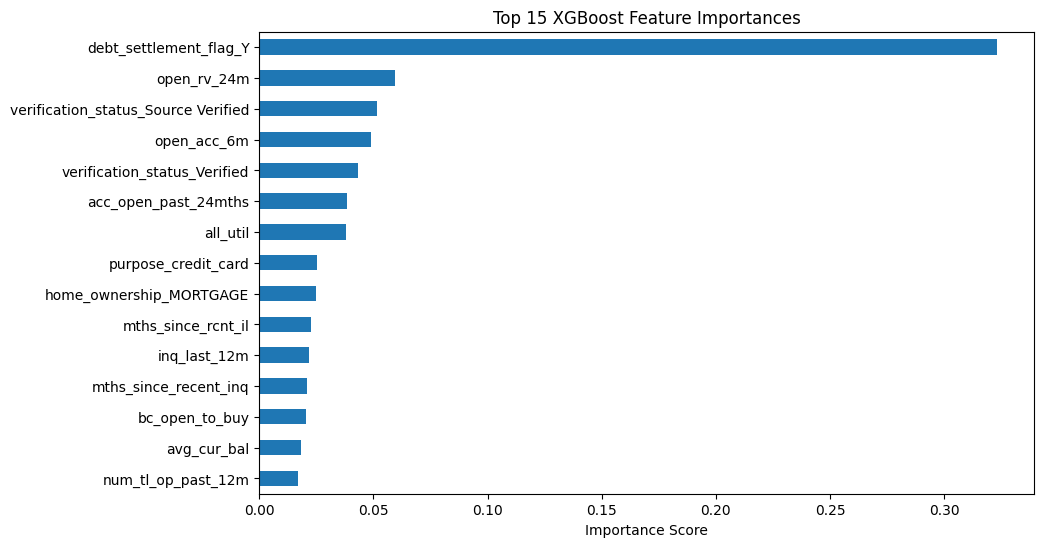


Top 15 Most Important Features:
debt_settlement_flag_Y                 0.323262
open_rv_24m                            0.059320
verification_status_Source Verified    0.051501
open_acc_6m                            0.049162
verification_status_Verified           0.043177
acc_open_past_24mths                   0.038305
all_util                               0.038217
purpose_credit_card                    0.025104
home_ownership_MORTGAGE                0.024855
mths_since_rcnt_il                     0.022889
inq_last_12m                           0.021846
mths_since_recent_inq                  0.020908
bc_open_to_buy                         0.020624
avg_cur_bal                            0.018406
num_tl_op_past_12m                     0.016909
dtype: float32


In [38]:

# --- 1. Prepare and Split Data (Recap from previous steps) ---

# Assuming 'df' is the final cleaned and feature-engineered DataFrame
if 'default_flag' not in df.columns:
    print("Error: 'default_flag' column not found. Please ensure the target variable is correctly named.")
else:
    X = df.drop('default_flag', axis=1) # Features
    y = df['default_flag']             # Target

    # Split Data: 80% Training, 20% Testing
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Identify non-binary numeric columns for scaling
    # Assuming OHE columns are boolean/uint8; focus on floats/larger integers
    numeric_cols_to_scale = X_train.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns.tolist()

    # Apply Robust Scaling (important for handling outliers)
    scaler = RobustScaler()
    X_train[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
    X_test[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])

    print("Data splitting and scaling complete.")
    print(f"X_train shape: {X_train.shape}")
    print(f"Default rate in train set: {y_train.mean():.4f}")

    # --- 2. Train the XGBoost Model ---

    # Get the ratio of non-default to default cases for weighted training
    # This addresses the class imbalance (crucial for credit risk)
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"Using scale_pos_weight: {scale_pos_weight:.2f} to handle class imbalance.")

    # Initialize the XGBoost Classifier
    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5, # Common initial hyperparameter settings
        scale_pos_weight=scale_pos_weight, # Applying the weight for imbalance
        tree_method='hist' # Efficient tree building method
    )

    print("\nStarting XGBoost training...")
    xgb_model.fit(X_train, y_train)
    print("XGBoost training complete.")

    # --- 3. Evaluate the Model ---

    # Get probability predictions (needed for AUC)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

    # Get hard predictions (needed for Confusion Matrix)
    # Use a default threshold of 0.5 for now
    y_pred = xgb_model.predict(X_test)

    # --- Metrics for Credit Risk ---

    # 1. AUC-ROC Score
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nModel Performance on Test Set:")
    print(f"Area Under the ROC Curve (AUC-ROC): {roc_auc:.4f}")
    #

    # 2. Confusion Matrix and Classification Report (using 0.5 threshold)
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix (Threshold=0.5):")
    # Rows: Actual (0: Paid, 1: Default), Columns: Predicted
    print(cm)

    # 3. Classification Report (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # --- 4. Feature Importance ---

    # Extract feature importance and visualize the top N features
    feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
    top_n = 15
    plt.figure(figsize=(10, 6))
    feature_importances.nlargest(top_n).sort_values(ascending=True).plot(kind='barh')
    plt.title(f'Top {top_n} XGBoost Feature Importances')
    plt.xlabel('Importance Score')
    plt.show()
    #

    print(f"\nTop {top_n} Most Important Features:")
    print(feature_importances.nlargest(top_n))

In [40]:
# Identify any columns that are NOT numeric, bool, or category
invalid_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Columns causing the error: {invalid_cols}")

Columns causing the error: []


In [41]:
X_test.head()

,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,pub_rec,collections_12_mths_ex_med,policy_code,acc_now_delinq,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,application_type_Joint App,hardship_flag_Y,debt_settlement_flag_Y
762757,0.869820,-0.297872,-0.516283,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
353972,0.857586,0.106383,0.752184,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1317636,-0.128600,-0.468085,0.101668,0.0,1.0,10.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1969638,-0.737181,0.319149,-0.543288,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1205134,0.324163,0.212766,-0.870532,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [46]:
import shap

# Initialize the Explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Let's find one person the model CORRECTLY identified as a high risk (True Positive)
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['prob'] = xgb_model.predict_proba(X_test)[:, 1]

# Pick a high-risk candidate (Probability > 0.7)
high_risk_sample = test_results[test_results['prob'] > 0.7].iloc[0]
sample_idx = high_risk_sample.name # Get original index

In [60]:
from google.cloud import aiplatform

# Define your project variables
PROJECT_ID = "soral-vertex-a"
REGION = "us-central1"
BUCKET_URI = "gs://soral-credit-risk-model_bucket" # Used for storing model artifacts

# Initialize the Vertex AI SDK
aiplatform.init(project=PROJECT_ID, location=REGION, staging_bucket=BUCKET_URI)

print(f"Vertex AI SDK initialized for project {PROJECT_ID}")

Vertex AI SDK initialized for project soral-vertex-a


In [61]:
from google.colab import auth
auth.authenticate_user()

import vertexai
vertexai.init(project="soral-vertex-a", location="us-central1")

In [62]:
import vertexai
from vertexai.generative_models import GenerativeModel

# Double-check the project ID is exactly 'soral-vertex-a'
PROJECT_ID = "soral-vertex-a"
LOCATION = "us-central1"

vertexai.init(project=PROJECT_ID, location=LOCATION)

try:
    # Use the base name; Vertex AI handles the versioning
    model = GenerativeModel("gemini-2.0-flash-lite-001")
    response = model.generate_content("Is the API working?")
    print("Success:", response.text)
except Exception as e:
    print("Error still persists:", e)

Success: I am a large language model, trained by Google. I do not have access to real-time information about external APIs. Therefore, I cannot tell you definitively if a specific API is working at this moment.

To check if an API is working, you will need to:

*   **Consult the API provider's documentation:** This is the most reliable source of information. The documentation often includes status pages, error codes, and troubleshooting guides.
*   **Check the API's status page:** Many API providers have dedicated status pages that display the current operational status of their APIs.
*   **Test the API directly:** Use tools like `curl`, `Postman`, or a programming language (like Python with `requests`) to send requests to the API and check the response.
*   **Review error messages:** If you are trying to use the API and encounter errors, carefully read the error messages. They often provide clues about the problem.
*   **Search for known issues:** Check online forums, social media, or

In [66]:
# Get SHAP values for this specific high-risk sample
sample_position = X_test.index.get_loc(sample_idx)
feature_importance = pd.Series(shap_values[sample_position], index=X_test.columns)

# Get top 2 reasons for denial
top_reasons = feature_importance.sort_values(ascending=False).head(5).index.tolist()

model = GenerativeModel("gemini-2.0-flash-lite-001")


prompt = f"""
The loan applicant was denied.
Technical reasons: {top_reasons}.
Applicant Details: {X_test.loc[sample_idx].to_dict()}

Write a professional and supportive "Adverse Action Notice".
Explain clearly why they were denied without using technical jargon.
Suggest one way they can improve their financial profile for a future application.

The name of the lender is XYZ, please tell them to also consider other products and give suggestions that they can ask any questions in the chat window
"""

response = model.generate_content(prompt)

print(f"--- TEST CASE RESULTS (Index: {sample_idx}) ---")
print(f"Probability of Default: {high_risk_sample['prob']:.2%}")
print(f"Top XAI Reasons: {top_reasons}")
print("\n--- AI Generated Letter ---")
print(response.text)

--- TEST CASE RESULTS (Index: 1317636) ---
Probability of Default: 70.94%
Top XAI Reasons: ['bc_open_to_buy', 'mths_since_recent_inq', 'percent_bc_gt_75', 'all_util', 'annual_inc']

--- AI Generated Letter ---
**XYZ Loan Adverse Action Notice**

Dear [Applicant Name],

We regret to inform you that your loan application with XYZ has been denied. This decision was based on a review of your application and your overall financial profile.

**Reason for Denial:**

The primary reasons for this decision are related to your credit history and current financial standing. Specifically, our review indicated:

*   **Available Credit:** Your available credit across some of your credit accounts is not at a good place right now.
*   **Recent Credit Inquiries:** There have been recent inquiries on your credit report.
*   **High Credit Utilization on Certain Accounts:** The amount of credit you are using on some of your credit accounts is too high.
*   **Total Credit Utilization:** Your total credit ut